# 20_异常值处理方法-分箱法处理

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇数据：`dataset/AmesHousing.csv`。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。
- 统一 AmesHousing 中实际存在的 Gr Liv Area 字段。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


本小节咱们来聊聊异常值处理方法常用的**分箱法处理**\~

首先，大体解释异常值和异常值处理：

**异常值**：就是数据里面那些特别奇怪、不正常的数据点。比如一组人的身高数据，绝大多数在150-190厘米之间，但有一个数据是500厘米，这个500厘米就很可能是异常值。

**异常值处理**：就是我们在分析数据之前，要先找到这些“奇怪”的数据，并决定如何处理它，不能让它们影响我们后续分析的结果。

### 1. 什么是分箱法处理？

**分箱法**，通俗来说，就是把数据的数值范围切成几个“小箱子”（区间），然后把数据按箱子分组。这样我们就能更清楚地看到数据分布，也方便找到异常值。

比如：你有一堆人的年龄数据，0-100岁，你可以把它分成5个箱子：

- 0-20岁
- 21-40岁
- 41-60岁
- 61-80岁
- 81-100岁

然后看每个箱子里有多少人，哪个箱子异常多或异常少。

**异常值处理时的分箱法**，就是利用这个把数据切箱子的思路，帮助识别哪些箱子里的数据可能是异常值，或者把异常值归到特殊箱子里，方便后续处理。

### 2. 为什么分箱法能处理异常值？

异常值通常落在数据极端的位置（特别大或特别小），用分箱法后：

异常值可能被划分到某个极端的箱子里（比如最大值箱），通过观察箱子里数据的数量和分布，能发现异常箱，进而判断哪些是异常值。

对异常箱里的数据，可以选择修正、删除或替换。

### 3. 分箱法核心原理

假设你有一组数据：


$$
X = \{x_1, x_2, ..., x_n\}
$$


你想把数据分成 $k$ 个箱子，箱子用区间表示：


$$
B_1 = [a_0, a_1), \quad B_2 = [a_1, a_2), \quad ..., \quad B_k = [a_{k-1}, a_k]
$$


其中：

- $a_0 = \min(X)$ 是数据的最小值
- $a_k = \max(X)$ 是数据的最大值
- 其余的 $a_i$ 是划分的边界点

**如何确定边界点** $a_i$**？**

主要有两种方式：

**1. 等宽分箱（Equal Width Binning）**：每个箱子的宽度相等。

箱宽：


$$
w = \frac{\max(X) - \min(X)}{k}
$$


则边界为：


$$
a_i = \min(X) + i \times w, \quad i=0,1,...,k
$$


**2. 等频分箱（Equal Frequency Binning）**：每个箱子包含大致相同数量的数据点。

这时，边界点 $a_i$ 是数据中按排序后对应的百分位数位置的数值，比如分成5箱，边界就是20%、40%、60%、80%的位置数据值。

#### 判断异常值

异常值往往位于最左或最右的箱子里，也可能是那些箱子里数据量特别少的值。

具体数学上，可以结合箱子中数据分布统计，比如：

- 箱子中数据量 $n_i$
- 数据的平均值 $\bar{x_i}$
- 数据的标准差 $\sigma_i$

如果某个箱子里的数据量极少，且与其他箱子差异较大，里面的点可能是异常。

#### 公式推理：分箱异常值检测的思路

先分箱：


$$
X \to \{B_1, B_2, ..., B_k\}
$$


对每个箱子 $B_i$，计算统计量：


$$
n_i = \text{箱内数据个数}, \quad \bar{x_i} = \frac{1}{n_i} \sum_{x_j \in B_i} x_j, \quad \sigma_i = \sqrt{\frac{1}{n_i} \sum_{x_j \in B_i} (x_j - \bar{x_i})^2}
$$


找出极端箱子，比如 $B_1, B_k$（最左和最右），或数据量远小于其他箱的箱子。

对箱子里的数据，再进行异常值判断，比如：

- 是否超出该箱的正常范围（可以用箱内均值 ± 几倍标准差）
- 是否低于某个阈值（根据业务经验）

### 4. 分箱法处理异常值的算法流程

1. **准备数据**收集需要处理的数值型数据 $X$。
2. **选择分箱方法**

   - 等宽分箱或等频分箱
   - 设定箱子数 $k$
3. **计算分箱边界**

   - 等宽分箱计算宽度 $w$ 和边界点 $a_i$
   - 等频分箱找到数据的分位点作为边界
4. **对数据进行分箱**每个数据 $x_j$ 归入对应的箱子 $B_i$，满足：


$$
x_j \in B_i \iff a_{i-1} \leq x_j < a_i
$$


1. **统计箱内数据**计算每个箱子内的数据量 $n_i$、均值 $\bar{x_i}$、标准差 $\sigma_i$等。
2. **识别异常箱**根据统计量和业务规则，找出异常箱（通常是数据量极少或边界箱子）
3. **识别箱内异常值**在异常箱内，进一步筛选异常点，比如超过均值 ± 3倍标准差的点。
4. **处理异常值**

   - 替换（用箱内均值、中位数替换）
   - 删除（直接剔除）
   - 标记（做标记，后续特殊处理）

### 5. 简单举例说明

假设有以下数据（单位：身高，厘米）：


$$
X = \{150, 152, 155, 158, 160, 162, 165, 170, 172, 175, 300\}
$$


明显，300是异常值。

设 $k=3$ 等宽分箱，计算边界：


$$
\min(X) = 150, \quad \max(X) = 300
$$


宽度：


$$
w = \frac{300 - 150}{3} = 50
$$


分箱：


$$
B_1 = [150, 200)
$$


$$
B_2 = [200, 250)
$$


$$
B_3 = [250, 300]
$$


- 把数据放入箱子：$B_1$ 有：150, 152, 155, 158, 160, 162, 165, 170, 172, 175（共10个）$B_2$ 无数据$B_3$ 有：300（共1个）
- 发现 $B_2$ 没数据，$B_3$ 只有一个数据，而且值特别大，说明300是异常值。

总的来说，分箱法就是把数据分成几段区间，观察每个箱子的情况，特别是那些边界箱。

边界箱里出现少量数据或者特别极端的数值，往往是异常值。

利用箱子统计的均值和标准差，也可以更细致判断异常。

## 综合案例

我们要处理一个关于**房价预测**的数据集。这个数据集包含了房屋的基本特征（面积、卧室数、建造年份等），以及最终成交价格。我们的目标不是建模预测房价，而是专注于使用**分箱法**识别并处理**异常值**，例如房价异常高的豪宅、面积极小的劣质房源等。

数据集获取：

<callout emoji="🏆">
公众号：深夜努力写Python，后台回复「数据集」即可拿到\~
</callout>

我们将重点分析：

- 面积（`GrLivArea`）字段中的异常值
- 成交价（`SalePrice`）字段中的异常值

### 导入库和加载数据

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 加载数据
df = pd.read_csv(DATA_DIR / 'AmesHousing.csv')

# 显示基本信息
print(df[['Gr Liv Area', 'SalePrice']].describe())

       Gr Liv Area      SalePrice
count  2930.000000    2930.000000
mean   1499.690444  180796.060068
std     505.508887   79886.692357
min     334.000000   12789.000000
25%    1126.000000  129500.000000
50%    1442.000000  160000.000000
75%    1742.750000  213500.000000
max    5642.000000  755000.000000


### 数据可视化（初步查看异常值）

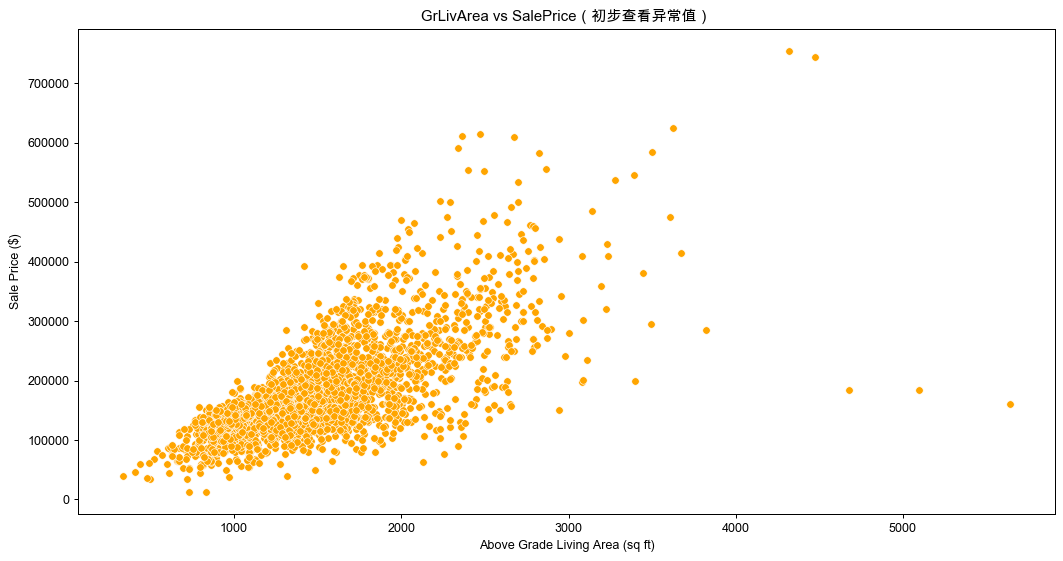

In [3]:
# 散点图观察GrLivArea与SalePrice关系
plt.figure(figsize=(14, 7))
sns.scatterplot(data=df, x='Gr Liv Area', y='SalePrice', color='orange')
plt.title("GrLivArea vs SalePrice（初步查看异常值）")
plt.xlabel("Above Grade Living Area (sq ft)")
plt.ylabel("Sale Price ($)")
plt.show()

图中右下角可能存在**面积超大但价格异常低**的点，或面积极小价格极高的异常点。

![原文参考图，当前结果见代码输出](attachments/img_004.png)

### 使用分箱法检测异常值（以面积为例）

**1）选择分箱类型：等频分箱**

In [4]:
# 分箱数量
n_bins = 10

# 创建等频分箱（基于面积）
df['AreaBin'] = pd.qcut(df['Gr Liv Area'], q=n_bins, duplicates='drop')

**2）统计每个箱子的均值和标准差**

In [5]:
# 计算箱内均值和标准差
bin_stats = df.groupby('AreaBin')['SalePrice'].agg(['count', 'mean', 'std']).reset_index()
print(bin_stats)

            AreaBin  count           mean            std
0  (333.999, 923.9]    293  107625.085324   28070.255973
1   (923.9, 1064.8]    293  125142.515358   23781.220301
2  (1064.8, 1200.0]    306  133714.081699   28194.767060
3  (1200.0, 1327.6]    280  152844.146429   36539.571013
4  (1327.6, 1442.0]    296  163916.773649   39685.445189
5  (1442.0, 1560.0]    296  180728.104730   45652.494371
6  (1560.0, 1680.0]    293  195809.651877   54849.477868
7  (1680.0, 1838.0]    289  213024.986159   67863.948068
8  (1838.0, 2152.1]    291  235114.436426   77487.965384
9  (2152.1, 5642.0]    293  301873.873720  112246.556982


/var/folders/q6/v6bs8gb12gd1lh35j2b7z3sc0000gn/T/ipykernel_11341/301896078.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df.groupby('AreaBin')['SalePrice'].agg(['count', 'mean', 'std']).reset_index()


### 可视化每个箱子的统计特征

/var/folders/q6/v6bs8gb12gd1lh35j2b7z3sc0000gn/T/ipykernel_11341/2658383934.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='AreaBin', y='mean', data=bin_stats, palette='coolwarm')


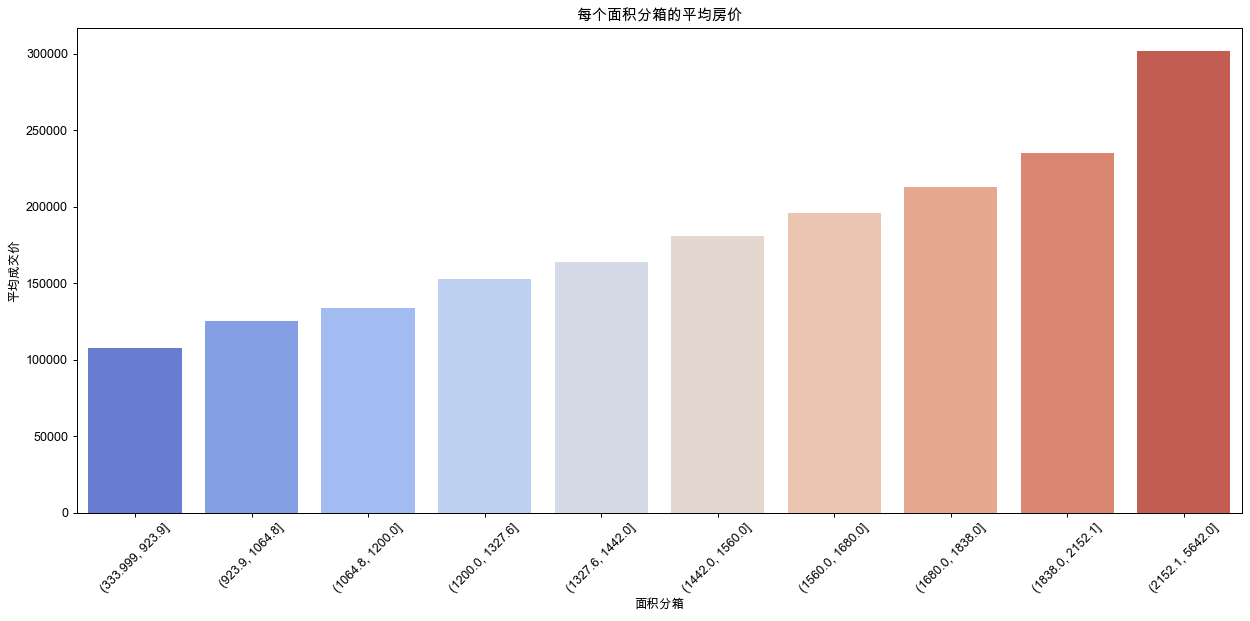

In [6]:
# 可视化箱子统计结果
plt.figure(figsize=(14, 7))
sns.barplot(x='AreaBin', y='mean', data=bin_stats, palette='coolwarm')
plt.xticks(rotation=45)
plt.title("每个面积分箱的平均房价")
plt.xlabel("面积分箱")
plt.ylabel("平均成交价")
plt.tight_layout()
plt.show()

可以看到某些箱子的平均价格远高或远低于其他箱，有可能存在异常值聚集。

![原文参考图，当前结果见代码输出](attachments/img_005.png)

### 标记异常箱子中的异常值

我们将每个箱子内的 SalePrice 用“均值 ± 2 倍标准差”规则来判断异常值：


$$
异常值范围： [\bar{x} - 2\sigma, \bar{x} + 2\sigma]
$$

In [7]:
# 将箱内均值和标准差合并到原数据
df = df.merge(bin_stats[['AreaBin', 'mean', 'std']], on='AreaBin', how='left')

# 计算异常值上下界
df['lower_bound'] = df['mean'] - 2 * df['std']
df['upper_bound'] = df['mean'] + 2 * df['std']

# 判断 SalePrice 是否为异常值
df['IsOutlier'] = (df['SalePrice'] < df['lower_bound']) | (df['SalePrice'] > df['upper_bound'])

# 显示异常值
outliers = df[df['IsOutlier']]
print(f"发现异常值数量：{outliers.shape[0]}")
print(outliers[['Gr Liv Area', 'SalePrice']].sort_values(by='Gr Liv Area', ascending=False).head())

发现异常值数量：133
      Gr Liv Area  SalePrice
1760         4476     745000
1767         4316     755000
2445         3627     625000
2450         3500     584500
2330         3390     545224


### 将异常值可视化标记出来

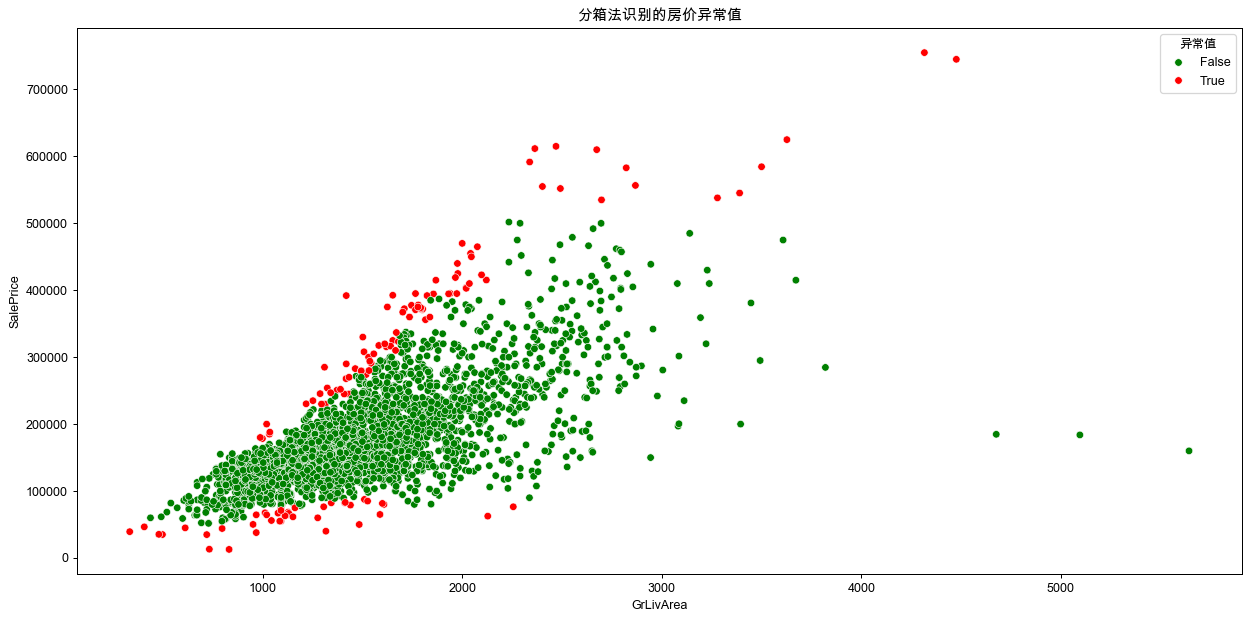

In [8]:
# 标记颜色
plt.figure(figsize=(14, 7))
sns.scatterplot(data=df, x='Gr Liv Area', y='SalePrice', hue='IsOutlier', palette={True: 'red', False: 'green'})
plt.title("分箱法识别的房价异常值")
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.legend(title='异常值')
plt.tight_layout()
plt.show()

可以看到红点即为异常值，许多出现在面积最大箱、最小箱中，这正是**分箱法的优势所在**。

![原文参考图，当前结果见代码输出](attachments/img_006.png)

### 处理异常值（删除或填充）

这里我们选择删除异常值（也可以替换为箱内均值或中位数）：

In [9]:
# 删除异常值
df_cleaned = df[~df['IsOutlier']].copy()

# 查看删除后数据量
print(f"清理后数据量：{df_cleaned.shape[0]}，原始数据量：{df.shape[0]}")

清理后数据量：2797，原始数据量：2930


### 对比处理前后数据分布

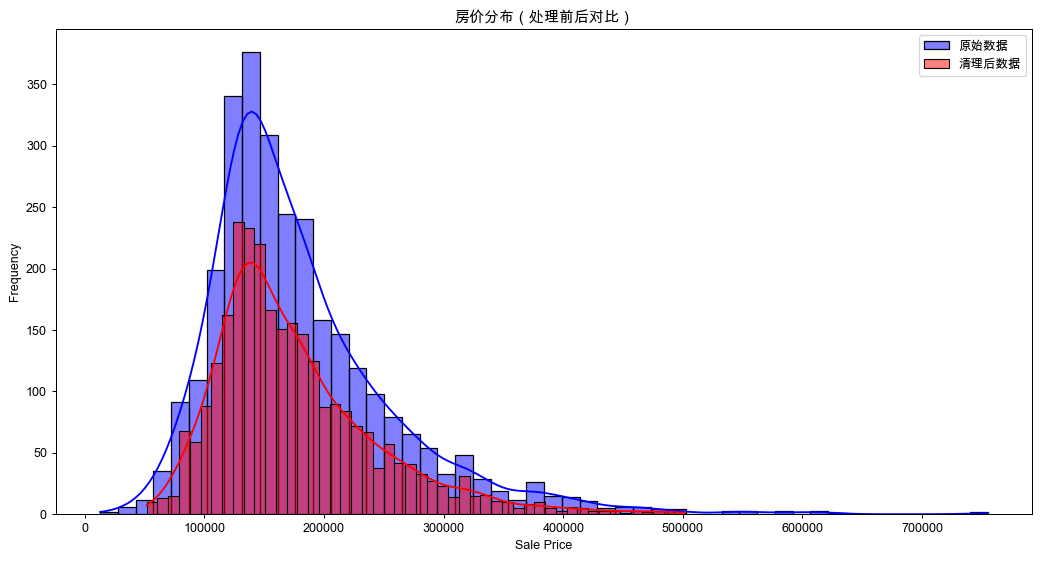

In [10]:
# 可视化房价直方图对比
plt.figure(figsize=(14, 7))
sns.histplot(df['SalePrice'], bins=50, color='blue', label='原始数据', kde=True)
sns.histplot(df_cleaned['SalePrice'], bins=50, color='red', label='清理后数据', kde=True)
plt.title("房价分布（处理前后对比）")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")
plt.legend()
plt.show()

清理后的数据更加集中，没有极端高价影响整体分布。

![原文参考图，当前结果见代码输出](attachments/img_007.png)

### 每一步操作总结

1. **分箱**：我们使用 **等频分箱（qcut）**，将面积划分为 10 个频率相等的区间，目的是让每个箱子有相近数量的数据。
2. **统计特征**：计算每个箱子中房价的均值与标准差，这是用于识别异常值的基准线。
3. **识别异常值**：使用箱内“平均值 ± 2 倍标准差”来判断是否偏离正常分布，这种方法比全局均值更精细。
4. **可视化验证**：通过颜色标记可清晰看出哪些数据在分布上存在异常，是分箱法辅助分析的亮点。
5. **数据清洗**：对检测到的异常值进行删除，观察处理前后数据分布，验证其合理性。

### 分箱法处理异常值的优点和缺点

**优点**：

- **局部分析能力强**：不看全局，而看局部箱子内的分布，能识别微妙异常。
- **直观可视化**：分箱结果易于图表展示、分析理解。
- **适合非正态数据**：对偏态分布也适用，不依赖总体分布形状。
- **可结合业务规则**：灵活选择箱子数量、箱内判断标准。

**缺点**：

- **对箱子划分敏感**：不同分箱方式（等宽 vs 等频）结果不同。
- **参数依赖大**：箱子数、异常标准（如 ±2σ）影响较大。
- **边界问题**：落在边界附近的数据可能误判。
- **不能自动识别所有类型异常**：如孤立点或复杂异常，可能漏判。

### 在哪些情况下适合用分箱法处理异常值？

1. **数据呈偏态分布或分布不清楚时**：全局统计无法识别异常，局部箱子判断更敏感。
2. **数据量较大时**：分箱法对大数据集处理较快，稳定性好。
3. **业务规则明确时**：可以手动定义分箱范围、标准，利于业务专家参与分析。
4. **数据维度较少时（单变量异常检测）**：分箱法特别适合处理单一特征的异常值，比如收入、年龄、面积等。

## 总结

虽然分箱法存在一定的局限性，但其**简单、直观、灵活**的优势，依然让它成为数据清洗阶段非常重要的工具，特别适合日常使用。